![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [5]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [6]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

,count
airline,
United,3822
US Airways,2913
American,2759
Southwest,2420
Delta,2222
Virgin America,504


<Axes: title={'center': 'Sentiminetos por aerolínea'}, xlabel='airline'>

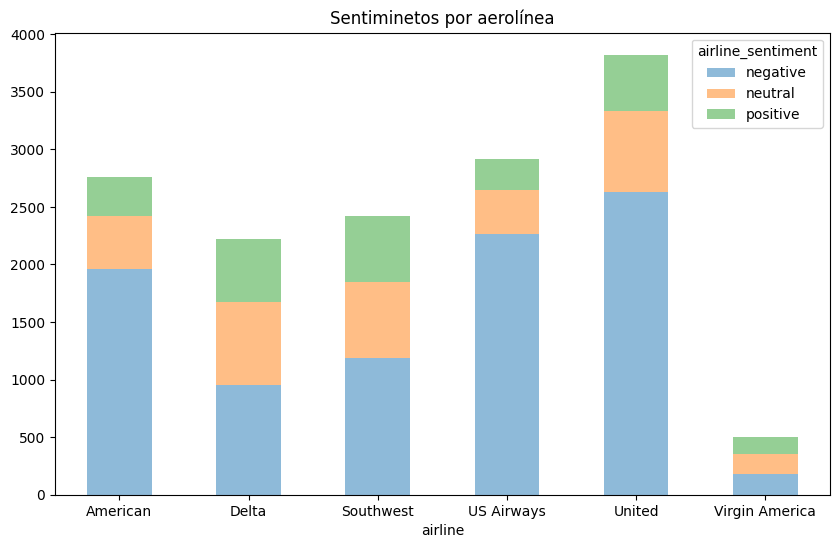

In [7]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")

### Liberias y Variables de interés y predicción

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer

In [9]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [10]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [15]:
# Celda 1
from sklearn.metrics import accuracy_score

vect = CountVectorizer()

X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

#Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_dtm, y_train)
y_pred = model.predict(X_test_dtm)

#Accuracy
accuracy_1 = accuracy_score(y_test, y_pred)

print("Accuracy CountVectorizer:", accuracy_1)

Accuracy CountVectorizer: 0.7711092715231788


### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [16]:
# Celda 2
vect = CountVectorizer(stop_words='english')

X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

#Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_dtm, y_train)
y_pred = model.predict(X_test_dtm)

#Accuracy
accuracy_2 = accuracy_score(y_test, y_pred)

print("Accuracy sin Stopwords:", accuracy_2)

Accuracy sin Stopwords: 0.761796357615894


### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [17]:
# Celda 3
# Importación de librerias
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
import nltk
nltk.download('wordnet')

# Función de lematización (con verbos)
def split_into_lemmas(text):
    words = text.lower().split()
    return [lemmatizer.lemmatize(word, pos='v') for word in words]

# Vectorización usando la función personalizada
vect = CountVectorizer(analyzer=split_into_lemmas)

X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

#Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_dtm, y_train)
y_pred = model.predict(X_test_dtm)

#Accuracy
accuracy_3 = accuracy_score(y_test, y_pred)

print("Accuracy Lematización verbos:", accuracy_3)

[nltk_data] Downloading package wordnet to /root/nltk_data...


Accuracy Lematización verbos: 0.7611754966887417


### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [26]:
# Celda 4
lemmatizer2 = WordNetLemmatizer()

#Lematización
def split_into_lemmas(text):
    words = text.lower().split()
    return [lemmatizer2.lemmatize(word, pos='v') for word in words]

#CounVectorizer sin Stopwords con lematización
vect = CountVectorizer(stop_words='english', analyzer=split_into_lemmas)

X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

#Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_dtm, y_train)
y_pred = model.predict(X_test_dtm)

#Accuracy
accuracy_4 = accuracy_score(y_test, y_pred)

print("Accuracy múltiples técnicas:", accuracy_4)

Accuracy múltiples técnicas: 0.7611754966887417


### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

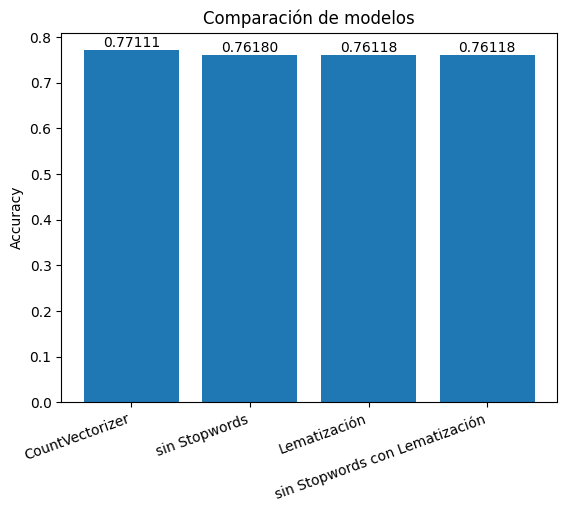

In [27]:
# Celda 5
modelo = ["CountVectorizer", "sin Stopwords", "Lematización", "sin Stopwords con Lematización"]
accuracy = [accuracy_1, accuracy_2, accuracy_3, accuracy_4]

#Gráfico
plt.figure()
bars = plt.bar(modelo, accuracy)
plt.xticks(rotation=20, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.5f}',ha='center', va='bottom')

plt.title("Comparación de modelos")
plt.ylabel("Accuracy")

plt.show()

Al comparar los diferentes modelos de Random Forest, se observa que el mejor desempeño se obtiene utilizando únicamente CountVectorizer sin aplicar técnicas adicionales de preprocesamiento, alcanzando un accuracy de 0.771. Por otro lado, los modelos que incorporan eliminación de stopwords y lematización presentan un desempeño ligeramente inferior, con valores de 0.761.

La principal ventaja del modelo que obtuvo el mayor accuracy (CountVectorizer) es que conserva toda la información original del texto, lo cual incluye palabras que pueden aportar un contexto o información relevante para la clasificación del sentimiento en este conjunto de datos. Además, el modelo Random Forest maneja de forma adecuada el ruido e identifica las relaciones complejas entre variables, lo que reduce la necesidad de un preprocesamiento más complejo.

En contraste, los modelos con menor accuracy (Lematización y eliminación de Stopwords+Lematización) corresponden a técnicas que generalmente presentan una mejoría en términos de la representación del texto. En este caso pueden estar eliminando información útil o simplificando en exceso el texto, lo que afecta negativamente la capacidad del modelo para diferenciar.

Estos resultados sugieren que el impacto del preprocesamiento depende del tipo de modelo utilizado. Asimismo, la diferencia de desempeño entre modelos es pequeña, lo que indica que el conjunto de datos es relativamente robusto frente a distintas técnicas de preprocesamiento.